## Ejercicio Python 1: Construcción de un portafolio eficiente con simulación

Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

1. Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.

Sara Hernandez Ochoa

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tickers = ["AAPL", "JPM", "KO"]

prices = yf.download(tickers, start="2021-01-01")["Close"]
prices

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,JPM,KO
Date,,,
2021-01-04,125.856712,110.051910,45.391964
2021-01-05,127.412773,110.650742,44.892952
2021-01-06,123.123848,115.846451,43.464775
2021-01-07,127.325264,119.650742,42.982979
2021-01-08,128.424194,119.782860,43.946571
...,...,...,...
2026-02-25,274.230011,303.299988,80.470001
2026-02-26,272.950012,306.130005,80.500000
2026-02-27,264.179993,300.299988,81.559998


**2. Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.**

In [3]:
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
mean_returns * 100

Ticker
AAPL    0.071732
JPM     0.088942
KO      0.048012
dtype: float64

In [4]:
cov_matrix = returns.cov()
cov_matrix

Ticker,AAPL,JPM,KO
Ticker,,,
AAPL,0.000308,0.000093,0.000047
JPM,0.000093,0.000236,0.000032
KO,0.000047,0.000032,0.000101


**4. Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.**

Para cada portafolio, calcula:

Rendimiento esperado.

Riesgo (desviación estándar).

Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

In [5]:
n = 10000
rf = 0.04

p_returns = np.zeros(n)
p_volatilities = np.zeros(n)
p_sharpes = np.zeros(n)
all_weights = np.zeros((n, len(tickers)))

for i in range(n):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights[i, :] = weights
    
    port_return = np.sum(weights * mean_returns)
    
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe_ratio = (port_return - rf) / port_volatility
    
    p_returns[i] = port_return
    p_volatilities[i] = port_volatility
    p_sharpes[i] = sharpe_ratio

In [6]:
min_vol_idx = np.argmin(p_volatilities)
max_ret_idx = np.argmax(p_returns)
max_sharpe_idx = np.argmax(p_sharpes)

print("Mejor Sharpe: Rendimiento=" + str(round(p_returns[max_sharpe_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[max_sharpe_idx], 4)))
print("Menor Riesgo: Rendimiento=" + str(round(p_returns[min_vol_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[min_vol_idx], 4)))
print("Mayor Rendimiento: Rendimiento=" + str(round(p_returns[max_ret_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[max_ret_idx], 4)))

Mejor Sharpe: Rendimiento=0.0007, Riesgo=0.0174
Menor Riesgo: Rendimiento=0.0006, Riesgo=0.009
Mayor Rendimiento: Rendimiento=0.0009, Riesgo=0.015


**5. Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:**

Identifica el portafolio de menor riesgo.

Identifica el portafolio de mayor rendimiento.

Identifica el portafolio con mayor Sharpe.

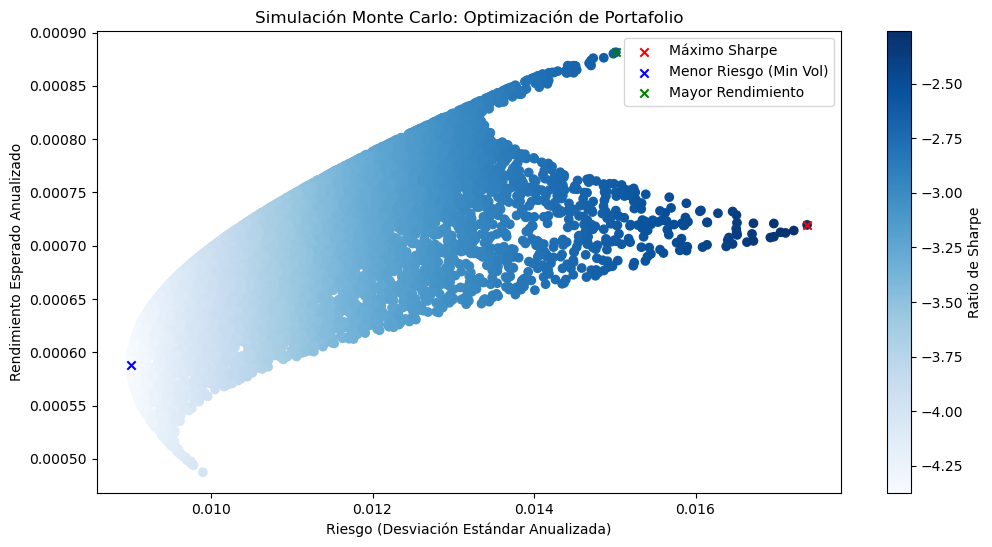

In [7]:
plt.figure(figsize=(12, 6))

plt.scatter(p_volatilities, p_returns, c=p_sharpes, cmap='Blues', marker='o')
plt.colorbar(label='Ratio de Sharpe')

plt.scatter(p_volatilities[max_sharpe_idx], p_returns[max_sharpe_idx], marker='x', color='r', label='Máximo Sharpe')

plt.scatter(p_volatilities[min_vol_idx], p_returns[min_vol_idx], marker='x', color='b', label='Menor Riesgo (Min Vol)')

plt.scatter(p_volatilities[max_ret_idx], p_returns[max_ret_idx], marker='x', color='g', label='Mayor Rendimiento')

plt.title('Simulación Monte Carlo: Optimización de Portafolio')
plt.xlabel('Riesgo (Desviación Estándar Anualizada)')
plt.ylabel('Rendimiento Esperado Anualizado')
plt.legend()
plt.show()

**6. Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué?**
De acuerdo con la simulación Monte Carlo, el portafolio con mayor rendimiento también presenta uno de los niveles más altos de riesgo. Por otro lado, el portafolio de menor riesgo ofrece un rendimiento considerablemente más bajo.

El portafolio con mayor ratio de Sharpe representa la mejor combinación entre riesgo y rendimiento, ya que maximiza el rendimiento por unidad de riesgo asumido. Aunque los valores del Sharpe son negativos (debido a que la tasa libre de riesgo del 4% es superior al rendimiento promedio de los portafolios), el portafolio con el Sharpe más alto sigue siendo el más eficiente dentro del conjunto simulado.

Por lo tanto, recomendaría el portafolio con mayor Sharpe, ya que ofrece el mejor equilibrio riesgo–rendimiento según los resultados obtenidos.

